In [7]:
import numpy as np
import netket as nk
from netket.operator.spin import sigmax, sigmaz
import jax
import matplotlib.pyplot as plt
import json
import flax.serialization as serialization
from scipy.ndimage import uniform_filter1d
import os
from tqdm import tqdm
from scipy.stats import gaussian_kde
from scipy.optimize import brentq

In [26]:
N = 20
N_A = 20
hamiltonian_idx = 2

if N==N_A:
    data_file = f"../data/{hamiltonian_idx}/N{N}/results_N{N}_vs_T.json"
else: 
    data_file = f"../data/{hamiltonian_idx}/N{N}_NA_{N_A}/results_N{N}_vs_T.json"
with open(data_file, "r") as f:
    data = json.load(f)
hamiltonian_file = f"../data/hamiltonians.json"
with open(hamiltonian_file, "r") as f:
    data_h = json.load(f)

T_array      = np.array(data["T"])
energy_results      = data["energy"]
entropy_results     = data["entropy"]
free_energy_results = data["free_energy"]
param_index  = data["param_index"]
J_ZZ = data_h['hamiltonian'][hamiltonian_idx]['J_ZZ']
J_XX = data_h['hamiltonian'][hamiltonian_idx]['J_XX']
h_x = data_h['hamiltonian'][hamiltonian_idx]['h_x']
h_z = data_h['hamiltonian'][hamiltonian_idx]['h_z']

print(f"J_ZZ = {J_ZZ}, J_XX = {J_XX}, h_x = {h_x}, h_z = {h_z}")

J_ZZ = -1.0, J_XX = 0.0, h_x = -1.1, h_z = 0.0


In [27]:
def hamiltonian_system_and_extended(J_ZZ, J_XX, h_x, h_z, N, hi_system, hi_extended):
    H_system = 0
    H_extended = 0
    for i in range(N):
        H_system+= h_x * sigmax(hi_system, i)
        H_system+= h_z * sigmaz(hi_system, i)
        H_system += J_ZZ * sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N)
        H_system += J_XX * sigmax(hi_system, i) @ sigmax(hi_system, (i + 1) % N)
        H_extended += h_x * sigmax(hi_extended, i)
        H_extended += h_z * sigmaz(hi_extended, i)
        H_extended += J_ZZ * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)
        H_extended += J_XX * sigmax(hi_extended, i) @ sigmax(hi_extended, (i + 1) % N)
    return H_system, H_extended

hi_system = nk.hilbert.Spin(s=1/2, N=N)
hi_extended = nk.hilbert.Spin(s=1/2, N=N+N_A)
H_system, H_extended = hamiltonian_system_and_extended(J_ZZ, J_XX, h_x, h_z, N, hi_system, hi_extended)

In [ ]:
save = False
jump_lines = False
derivative = False 
fontsize = 14

if save:
    import matplotlib
    import matplotlib.pyplot as plt
    matplotlib.use("pgf")
    matplotlib.rcParams.update({
        "pgf.texsystem": "pdflatex",
        "font.family": "serif",
        "text.usetex": True,
        "pgf.rcfonts": False,
        "font.size": fontsize,
        "axes.titlesize": fontsize,
        "axes.labelsize": fontsize,
        "legend.fontsize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "figure.titlesize": fontsize,
    })

    def save_fig(fig, name, subdir="plots/MRE"):
        base = os.path.join("..", subdir)
        os.makedirs(base, exist_ok=True)
        for ext in ("pgf", "pdf"):
            fig.savefig(os.path.join(base, f"{name}.{ext}"), bbox_inches="tight")
        print(f"Guardado: {base}/{name}.[pgf|pdf]")

def set_ylim_robust(ax, data_arrays, percentile=97):
    all_vals = np.concatenate([np.array(d).flatten() for d in data_arrays])
    all_vals = all_vals[np.isfinite(all_vals)]
    vmin = np.percentile(all_vals, 100 - percentile)
    vmax = np.percentile(all_vals, percentile)
    margin = 0.1 * (vmax - vmin)
    ax.set_ylim(vmin - margin, vmax + margin)

def smooth_and_diff(y, x, window=20):
    y_smooth = uniform_filter1d(np.array(y, dtype=float), size=window, mode='nearest')
    return np.gradient(y_smooth, x)

H_matrix = H_system.to_dense()
eigvals, eigvecs = np.linalg.eigh(H_matrix)

def compute_jump_temperatures(evals, tol=1e-10):
    unique_evals = []
    for e in evals:
        if not unique_evals or abs(e - unique_evals[-1]) > tol:
            unique_evals.append(e)
    unique_evals = np.array(unique_evals)
    T_jumps = []
    for n in range(1, len(unique_evals)):
        weights = unique_evals[n] - unique_evals[:n]
        E_bar = np.dot(unique_evals[:n], weights) / weights.sum()
        T_jumps.append((unique_evals[n] - E_bar) / 2)
    return np.array(T_jumps)

def canonical_ensemble(eigvals, eigvecs, T):
    log_pops = -eigvals / T
    log_pops -= np.max(log_pops)
    pops = np.exp(log_pops)
    pops /= pops.sum()
    energy = np.sum(pops * eigvals)
    mask = pops > 1e-15
    S_VN = -np.sum(pops[mask] * np.log(pops[mask]))
    return energy - T * S_VN, energy, S_VN

def renyi_exact(T, eigvals, tol=1e-12):
    from scipy.optimize import brentq

    eigvals = np.array(eigvals, dtype=float)

    def mre_weights(E_perp):
        w = np.maximum(0.0, E_perp - eigvals)
        Z = w.sum()
        if Z < tol:
            return None
        return w / Z

    def f_root(E_perp):
        w = mre_weights(E_perp)
        if w is None:
            return E_perp
        E_bar = np.dot(w, eigvals)
        return E_perp - (2 * T + E_bar)

    E_min = eigvals.min()
    E_max = eigvals.max() + 4 * T

    try:
        E_perp = brentq(f_root, E_min, E_max, xtol=1e-12)
    except ValueError:
        w = np.zeros(len(eigvals))
        w[0] = 1.0
    else:
        w = mre_weights(E_perp)

    E = np.dot(w, eigvals)
    purity = np.sum(w**2)
    S2 = -np.log(purity)
    F = E - T * S2

    return F, E, S2

temperatures = np.linspace(0.05, 4, 200)
F_arr, E_arr, S_arr = np.array([canonical_ensemble(eigvals, eigvecs, T) for T in temperatures]).T
F_R, E_R, S2_R = np.array([renyi_exact(T, eigvals) for T in temperatures]).T

if jump_lines:
    T_jumps = compute_jump_temperatures(eigvals)
    T_jumps_visible = T_jumps[T_jumps <= temperatures[-1]]
cmap = plt.cm.tab10

def add_jump_lines(ax):
    for i, Tn in enumerate(T_jumps_visible):
        ax.axvline(Tn, color=cmap(i % 10), lw=1.0, ls='--', alpha=0.7)

if derivative:
    SMOOTH_WINDOW = 20
    PERCENTILE    = 97

    dF_dT_renyi = smooth_and_diff(free_energy_results, T_array, window=SMOOTH_WINDOW)
    dE_dT_renyi = smooth_and_diff(energy_results,      T_array, window=SMOOTH_WINDOW)
    dS_dT_renyi = smooth_and_diff(entropy_results,     T_array, window=SMOOTH_WINDOW)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

axes[0,0].plot(temperatures, F_arr, color='C0', label=r'$F_\mathrm{Gibbs}$')
axes[0,0].plot(temperatures, F_R, color='green', label=r'$F_\mathrm{Renyi} \, (ED)$')
axes[0,0].plot(T_array, free_energy_results, 'x', color='C1', markersize=5, alpha=0.9,
               label=r'$F_\mathrm{Renyi}$')

axes[0,0].set_ylabel(r'$F$')
axes[0,0].set_title(r'(a) Free energy')
axes[0,0].set_xlabel(r'$T$')
axes[0,0].legend(fontsize=fontsize-1)
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(temperatures, E_arr, color='C0', label=r'$\langle H\rangle_\mathrm{Gibbs}$')
axes[0,1].plot(temperatures, E_R, color='green', label=r'$\langle H\rangle_\mathrm{Renyi} \, (ED)$')
axes[0,1].plot(T_array, energy_results, 'x', color='C1', markersize=5, alpha=0.9,
               label=r'$\langle H\rangle_\mathrm{Renyi}$')

axes[0,1].set_ylabel(r'$\langle H\rangle$')
axes[0,1].set_title(r'(b) Energy')
axes[0,1].set_xlabel(r'$T$')
axes[0,1].legend(fontsize=fontsize-1)
axes[0,1].grid(True, alpha=0.3)

axes[0,2].plot(temperatures, S_arr, color='C0', label=r'$S_\mathrm{VN}$')
axes[0,2].plot(temperatures, S2_R, color='green', label=r'$S_\mathrm{Renyi} \, (ED)$')
axes[0,2].plot(T_array, entropy_results, 'x', color='C1', markersize=5, alpha=0.9,
               label=r'$S_2$')

axes[0,2].set_ylabel(r'$S$')
axes[0,2].set_title(r'(c) Entropy')
axes[0,2].set_xlabel(r'$T$')
axes[0,2].legend(fontsize=fontsize-1)
axes[0,2].grid(True, alpha=0.3)

if derivative:
    axes[1,0].scatter(T_array, dF_dT_renyi, color='C1', s=8, zorder=3,
                      label=r'$dF/dT\ \mathrm{(Renyi)}$')

    set_ylim_robust(axes[1,0], [dF_dT_renyi], percentile=PERCENTILE)
    axes[1,0].set_xlabel(r'$T$')
    axes[1,0].set_ylabel(r'$dF/dT$')
    axes[1,0].set_title(r'$dF/dT$')
    axes[1,0].legend(fontsize=fontsize-1)
    axes[1,0].grid(True, alpha=0.3)

    axes[1,1].scatter(T_array, dE_dT_renyi, color='C1', s=8, zorder=3,
                      label=r'$dE/dT\ \mathrm{(Renyi)}$')

    set_ylim_robust(axes[1,1], [dE_dT_renyi], percentile=PERCENTILE)
    axes[1,1].set_xlabel(r'$T$')
    axes[1,1].set_ylabel(r'$dE/dT$')
    axes[1,1].set_title(r'$d\langle H\rangle/dT$')
    axes[1,1].legend(fontsize=fontsize-1)
    axes[1,1].grid(True, alpha=0.3)

    axes[1,2].scatter(T_array, dS_dT_renyi, color='C1', s=8, zorder=3,
                      label=r'$dS_2/dT\ \mathrm{(Renyi)}$')

    set_ylim_robust(axes[1,2], [dS_dT_renyi], percentile=PERCENTILE)
    axes[1,2].set_xlabel(r'$T$')
    axes[1,2].set_ylabel(r'$dS_2/dT$')
    axes[1,2].set_title(r'$dS_2/dT$')
    axes[1,2].legend(fontsize=fontsize-1)
    axes[1,2].grid(True, alpha=0.3)
else:
    for j in range(3):
        axes[1,j].set_visible(False)

if jump_lines:
    for i in range(2):
        for j in range(3):
            if derivative or (not derivative and i == 0):
                if axes[i,j].get_visible():
                    add_jump_lines(axes[i,j])

fig.tight_layout()
if save:
    save_fig(fig, f"F_E_S_N{N}")
else: 
    plt.show()

In [28]:
def check_temperatures(N, N_A, hamiltonian_idx):
    if N==N_A:
        data_file = f"../data/{hamiltonian_idx}/N{N}/results_N{N}_vs_T.json"
    else:
        data_file = f"../data/{hamiltonian_idx}/N{N}_NA_{N_A}/results_N{N}_vs_T.json"
    with open(data_file, "r") as f:
        data = json.load(f)
    T_list = data["T"]
    return np.array(T_list)

def load_params(N, N_A, hamiltonian_idx, T, vstate):
    if N==N_A:
        data_file = f"../data/{hamiltonian_idx}/N{N}/results_N{N}_vs_T.json"
    else:
        data_file = f"../data/{hamiltonian_idx}/N{N}_NA_{N_A}/results_N{N}_vs_T.json"
    with open(data_file, "r") as f:
        data = json.load(f)
    T_list = data["T"]
    # buscar T más cercana
    idx = int(np.argmin(np.abs(np.array(T_list) - T)))
    file_idx = data["param_index"][idx]
    if N==N_A:
        filename = f"../data/{hamiltonian_idx}/N{N}/params/params_{file_idx:04d}.msgpack"
    else:
        filename = f"../data/{hamiltonian_idx}/N{N}_NA_{N_A}/params/params_{file_idx:04d}.msgpack"
    with open(filename, "rb") as f:
        params = serialization.from_bytes(vstate.parameters, f.read())
    vstate.parameters = params

def canonical_expectation(O, T, eigvals, eigvecs):
    """
    Expectation value <O> en el ensemble canónico a temperatura T.

    Parámetros
    ----------
    O : NetKet operator
    T : float
    eigvals : ndarray
    eigvecs : ndarray

    Returns
    -------
    float
    """

    # convertir operador a matriz densa
    O_matrix = O.to_dense()

    # poblaciones de Boltzmann (estables numéricamente)
    log_pops = -eigvals / T
    log_pops -= np.max(log_pops)

    pops = np.exp(log_pops)
    pops /= pops.sum()

    # <n|O|n>
    O_diag = np.einsum(
        "ij,ji->i",
        np.conj(eigvecs.T),
        O_matrix @ eigvecs,
    )

    # promedio térmico
    return np.sum(pops * O_diag).real

def gibbs_thermodynamic_limit(T_array, J, h):
    """
    Calcula observables en el límite termodinámico para el modelo de Ising
    con campo transversal usando la solución analítica.
    """
    Nk = 4000
    k = np.linspace(0, np.pi, Nk)
    dk = np.pi / Nk
    energies_td = []
    sx_td = []
    szz_td = [] 
    for T in T_array:
        beta = 1.0 / T
        eps_k = 2 * np.sqrt(J**2 + h**2 - 2 * J * h * np.cos(k))
        tanh_term = np.tanh(beta * eps_k / 2)
        # Energía por sitio 
        e = - np.sum((eps_k / 2) * tanh_term) * dk / np.pi
        # <σx>
        mx = np.sum((h - J * np.cos(k)) / eps_k * tanh_term) * dk / np.pi
        # <σz σz>
        corr = np.sum((J - h * np.cos(k))/eps_k* tanh_term) * dk / np.pi
        energies_td.append(e)
        szz_td.append(corr*2)
        sx_td.append(mx*2)   
    return np.array(energies_td), np.array(sx_td), np.array(szz_td)


def gibbs_jordan_wigner_finite(N, J, h, T_array):
    """
    Energía, <σx> y <σzσz> del ensemble de Gibbs para el modelo de Ising
    cuántico 1D con PBC, via solución exacta Jordan-Wigner para N finito.

    Devuelve arrays (energía/sitio, sx, szz) para cada T en T_array.
    """
    m = np.arange(N)

    # Sectores NS (antiperiódico) y R (periódico)
    k_NS = 2 * np.pi * (m + 0.5) / N
    k_R  = 2 * np.pi * m / N

    def eps(k):
        return 2 * np.sqrt(h**2 + J**2 + 2 * h * J * np.cos(k))

    eps_NS = eps(k_NS)
    eps_R  = eps(k_R)

    # Coeficientes de Bogoliubov para los operadores
    def cos_theta(k):
        e = eps(k)
        return (h + J * np.cos(k)) / (e / 2 + 1e-300)

    def sin_theta(k):
        e = eps(k)
        return (J * np.sin(k)) / (e / 2 + 1e-300)

    E_list, sx_list, szz_list = [], [], []

    for T in T_array:
        beta = 1.0 / T

        def tanh_h(e):
            return np.tanh(beta * e / 2)

        th_NS = tanh_h(eps_NS)
        th_R  = tanh_h(eps_R)

        # --- log Z para los cuatro sectores (numéricamente estable) ---
        lZ_cNS = np.sum(np.log(2 * np.cosh(beta * eps_NS / 2)))
        lZ_sNS = np.sum(np.log(np.abs(2 * np.sinh(beta * eps_NS / 2)) + 1e-300))
        lZ_cR  = np.sum(np.log(2 * np.cosh(beta * eps_R  / 2)))
        lZ_sR  = np.sum(np.log(np.abs(2 * np.sinh(beta * eps_R  / 2)) + 1e-300))

        # Pesos relativos de cada sector en Z
        # Z = ½(Z_cNS + Z_sNS + Z_cR - Z_sR)
        lZ_max = max(lZ_cNS, lZ_sNS, lZ_cR, lZ_sR)
        w_cNS =  np.exp(lZ_cNS - lZ_max)
        w_sNS =  np.exp(lZ_sNS - lZ_max)
        w_cR  =  np.exp(lZ_cR  - lZ_max)
        w_sR  = -np.exp(lZ_sR  - lZ_max)
        Z_rel = 0.5 * (w_cNS + w_sNS + w_cR + w_sR)

        def sector_avg(obs_NS, obs_R):
            """Promedio ponderado entre sectores."""
            val = 0.5 * (w_cNS * obs_NS['c'] + w_sNS * obs_NS['s']
                       + w_cR  * obs_R['c']  + w_sR  * obs_R['s'])
            return val / Z_rel

        # --- Energía por sitio ---
        def E_sector(eps_k, th):
            return -np.sum(eps_k / 2 * th) / N

        # Sector cosh: ⟨nk⟩ = (1 - tanh)/2  →  E = -Σ (εk/2) tanh(βεk/2)
        # Sector sinh: ⟨nk⟩ = (1 + tanh)/2  → mismo resultado (simétrico)
        E_NS_c = E_sector(eps_NS, th_NS)
        E_NS_s = E_sector(eps_NS, -th_NS)   # sinh sector: n̄k flipped
        E_R_c  = E_sector(eps_R,  th_R)
        E_R_s  = E_sector(eps_R,  -th_R)

        E_density = sector_avg({'c': E_NS_c, 's': E_NS_s},
                               {'c': E_R_c,  's': E_R_s})

        # --- ⟨σx⟩ por sitio ---
        # En base de Bogoliubov: ⟨σx_i⟩ = (2/N) Σ_k cos(θk) (1 - 2⟨nk⟩)
        def sx_sector(k_arr, th):
            ct = cos_theta(k_arr)
            return np.sum(ct * th) / N   # factor 2/N * (1/2) tanh = tanh/N... ajustar signo

        # Fórmula estándar: ⟨mx⟩ = (1/N) Σk [(h + J cosk)/εk * tanh(βεk/2)]
        def sx_sec(k_arr, th):
            e = eps(k_arr)
            return np.sum((h + J * np.cos(k_arr)) / e * th) / N

        sx_NS_c =  sx_sec(k_NS,  th_NS)
        sx_NS_s =  sx_sec(k_NS, -th_NS)
        sx_R_c  =  sx_sec(k_R,   th_R)
        sx_R_s  =  sx_sec(k_R,  -th_R)

        sx_val = 2 * sector_avg({'c': sx_NS_c, 's': sx_NS_s},
                                {'c': sx_R_c,  's': sx_R_s})

        # --- ⟨σzσz⟩ (correlación NN) ---
        # ⟨ZiZi+1⟩ = (1/N) Σk [(J + h cosk)/εk * tanh(βεk/2)] * 2
        def szz_sec(k_arr, th):
            e = eps(k_arr)
            return np.sum((J + h * np.cos(k_arr)) / e * th) / N

        szz_NS_c =  szz_sec(k_NS,  th_NS)
        szz_NS_s =  szz_sec(k_NS, -th_NS)
        szz_R_c  =  szz_sec(k_R,   th_R)
        szz_R_s  =  szz_sec(k_R,  -th_R)

        szz_val = 2 * sector_avg({'c': szz_NS_c, 's': szz_NS_s},
                                 {'c': szz_R_c,  's': szz_R_s})

        E_list.append(E_density)
        sx_list.append(sx_val)
        szz_list.append(szz_val)

    return np.array(E_list), np.array(sx_list), np.array(szz_list)

def gibbs_jordan_wigner_finite_2(N, J, h, T_array, use_PBC=True):
    if use_PBC:
        # Sector PBC: k con condiciones periódicas
        # Los momentos permitidos son: k = 2πn/N con n = 0,1,...,N-1
        # Pero para fermiones, la condición de antiperiodicidad es natural
        n = np.arange(N)
        k = 2 * np.pi * n / N
        
        # Para PBC, solo retener modos con número impar de fermiones
        # Esto implica que k = π/N, 3π/N, ... (modos que no incluyen k=0)
        k = (2 * np.arange(1, N//2 + 1) - 1) * np.pi / N
        
    else:
        # APBC: k = π/N, 3π/N, ..., (N-1)π/N
        k = (2 * np.arange(1, N//2 + 1) - 1) * np.pi / N
    
    # Función de dispersión (como en Dziarmaga)
    def epsilon(k):
        return 2 * J * np.sqrt(1 + (h/J)**2 - 2*(h/J)*np.cos(k))
    
    eps_k = epsilon(k)
    
    # Coeficientes de Bogoliubov (cos θ_k)
    g = h / J
    cos_theta = (g - np.cos(k)) / np.sqrt(1 + g**2 - 2*g*np.cos(k) + 1e-12)
    sin_theta = np.sin(k) / np.sqrt(1 + g**2 - 2*g*np.cos(k) + 1e-12)
    
    E_vals, sx_vals, szz_vals = [], [], []
    
    for T in T_array:
        beta = 1.0 / T if T > 0 else np.inf
        
        if T == 0:
            # Estado fundamental
            th = np.ones_like(eps_k)
            # Energía del vacío de Bogoliubov
            E = -np.sum(eps_k / 2) / N
            # ⟨σx⟩ en el ground state
            sx = np.sum(cos_theta) / N
            # ⟨σzσz⟩ para NN
            # Usando la fórmula de QuSpin: ⟨σz_i σz_{i+1}⟩ = -⟨c_i^† c_{i+1} + c_{i+1}^† c_i + c_i^† c_{i+1}^† + c_i c_{i+1}⟩/2
            # En términos de Bogoliubov:
            szz = -np.sum(np.cos(k) * cos_theta) / N  # Aproximación, verificar
        else:
            # Temperatura finita
            th = np.tanh(beta * eps_k / 2)
            
            # Energía por sitio
            E = -np.sum(eps_k / 2 * th) / N
            
            # ⟨σx⟩ por sitio
            sx = np.sum(cos_theta * th) / N
            
            # ⟨σzσz⟩ para NN
            # Fórmula exacta de las correlaciones en el modelo de Ising
            # ⟨σz_i σz_{i+1}⟩ = - (1/N) Σ_k [cos k + (g - cos k) * tanh(βε_k/2)?]
            # De QuSpin: la correlación está relacionada con la energía
            szz = -np.sum((np.cos(k) + (g - np.cos(k)) * th) / (1 + 1e-12)) / N
        
        E_vals.append(E)
        sx_vals.append(sx)
        szz_vals.append(szz)
    
    return np.array(E_vals), np.array(sx_vals), np.array(szz_vals)

def gibbs_jordan_wigner_finite_3(N, J, h, T_array):

    m = np.arange(N)

    # Sector NS físico
    k = 2 * np.pi * (m + 0.5) / N

    # Dispersión
    eps = 2 * np.sqrt(
        J**2 + h**2 + 2 * J * h * np.cos(k)
    )

    E_list = []
    sx_list = []
    szz_list = []

    for T in T_array:

        beta = 1.0 / T

        th = np.tanh(beta * eps / 2)

        # =====================================================
        # Energía
        # =====================================================

        E = -np.sum(eps * th / 2) / N

        # =====================================================
        # <σx>
        # =====================================================

        sx = np.sum(
            2 * (h + J * np.cos(k)) / eps * th
        ) / N

        # =====================================================
        # <σzσz>
        # =====================================================

        szz = np.sum(
            2 * (J + h * np.cos(k)) / eps * th
        ) / N

        E_list.append(E)
        sx_list.append(sx)
        szz_list.append(szz)

    return (
        np.array(E_list),
        np.array(sx_list),
        np.array(szz_list)
    )

def gibbs_jordan_wigner_finite_4(N, J, h, T_array):

    m = np.arange(N)

    # Sector NS físico
    k = 2*np.pi*(m + 0.5)/N

    eps = 2*np.sqrt(
        J**2 + h**2 + 2*J*h*np.cos(k)
    )

    sx_list = []
    szz_list = []
    E_list = []

    for T in T_array:

        beta = 1/T

        th = np.tanh(beta*eps/2)

        # =====================================================
        # G_r
        # =====================================================

        def G(r):

            phase = np.exp(1j*k*r)

            numer = (
                h
                + J*np.cos(k)
                - 1j*J*np.sin(k)
            )

            return np.sum(
                phase * numer/eps * th
            ) / N

        G0 = np.real(G(0))
        G1 = np.real(G(1))
        Gm1 = np.real(G(-1))

        # =====================================================
        # Energía
        # =====================================================

        E = -np.sum(eps*th/2)/N

        # =====================================================
        # Observables exactos
        # =====================================================

        sx = 2*G0

        szz = 4*(Gm1*G1 - G0**2)

        E_list.append(E)
        sx_list.append(np.real(sx))
        szz_list.append(np.real(szz))

    return (
        np.array(E_list),
        np.array(sx_list),
        np.array(szz_list)
    )

def gibbs_jordan_wigner_finite_5(N, J, h, T_array):
    """
    Solución exacta Jordan-Wigner para Ising cuántico 1D con PBC, N finito.
    H = -J Σ ZiZi+1 - h Σ Xi
    """
    m = np.arange(N)
    k_NS = 2 * np.pi * (m + 0.5) / N   # sector antiperiódico (paridad par)
    k_R  = 2 * np.pi * m / N            # sector periódico    (paridad impar)

    def eps(k):
        return 2 * np.sqrt(J**2 + h**2 + 2*J*h*np.cos(k))

    eps_NS = eps(k_NS)
    eps_R  = eps(k_R)

    E_list, sx_list, szz_list = [], [], []

    for T in T_array:
        beta = 1.0 / T

        # log Z de cada sector (numéricamente estable)
        lZ_NS = np.sum(np.log(2 * np.cosh(beta * eps_NS / 2)))  # paridad par
        lZ_R  = np.sum(np.log(2 * np.cosh(beta * eps_R  / 2)))  # paridad impar, antes de proyección

        # Corrección de paridad para sector R:
        # Z_R_even = prod cosh + prod sinh  (estados con nº par de excitaciones)
        # Z_R_odd  = prod cosh - prod sinh  (estados con nº impar)
        # Solo contribuye la paridad correcta. Para PBC el sector físico es:
        # Z = Z_NS + Z_R_phys
        # con Z_R_phys = prod_k 2cosh + prod_k 2sinh  (ver Sachdev/Suzuki)

        lZ_R_sinh = np.sum(np.log(np.abs(2 * np.sinh(beta * eps_R / 2)) + 1e-300))

        # Energía de cada sector como -d/dbeta log Z
        def E_sector(eps_k):
            th = np.tanh(beta * eps_k / 2)
            return -np.sum(eps_k / 2 * th)

        def sx_sector(eps_k):
            e = eps_k  # eps_k = 2*sqrt(...)
            # componente: (h + J cos k) / (eps_k/2) * tanh(beta eps_k/2)
            k_arr = k_NS if np.allclose(eps_k, eps_NS) else k_R
            return np.sum((h + J * np.cos(k_arr)) / (eps_k / 2) * np.tanh(beta * eps_k / 2))

        def szz_sector(eps_k):
            k_arr = k_NS if np.allclose(eps_k, eps_NS) else k_R
            return np.sum((J + h * np.cos(k_arr)) / (eps_k / 2) * np.tanh(beta * eps_k / 2))

        # Pesos de cada sector
        lZ_max = max(lZ_NS, lZ_R, lZ_R_sinh)
        Z_NS       = np.exp(lZ_NS      - lZ_max)
        Z_R_cosh   = np.exp(lZ_R       - lZ_max)
        Z_R_sinh   = np.exp(lZ_R_sinh  - lZ_max)
        Z_tot = Z_NS + Z_R_cosh + Z_R_sinh  # ver nota abajo

        th_NS = np.tanh(beta * eps_NS / 2)
        th_R  = np.tanh(beta * eps_R  / 2)
        coth_R = 1.0 / np.tanh(np.clip(beta * eps_R / 2, 1e-10, None))

        # Energía media ponderada por sector
        E_NS = -np.sum(eps_NS / 2 * th_NS)
        E_R_c = -np.sum(eps_R  / 2 * th_R)
        E_R_s = -np.sum(eps_R  / 2 * coth_R)   # d/dbeta log sinh = coth

        E_tot = (Z_NS * E_NS + Z_R_cosh * E_R_c + Z_R_sinh * E_R_s) / Z_tot
        E_list.append(E_tot / N)

        # <σx> ponderado
        sx_NS  = np.sum((h + J * np.cos(k_NS)) / (eps_NS/2) * th_NS)
        sx_R_c = np.sum((h + J * np.cos(k_R))  / (eps_R /2) * th_R)
        sx_R_s = np.sum((h + J * np.cos(k_R))  / (eps_R /2) * coth_R)

        sx_tot = (Z_NS * sx_NS + Z_R_cosh * sx_R_c + Z_R_sinh * sx_R_s) / Z_tot
        sx_list.append(sx_tot / N)

        # <σzσz> ponderado
        szz_NS  = np.sum((J + h * np.cos(k_NS)) / (eps_NS/2) * th_NS)
        szz_R_c = np.sum((J + h * np.cos(k_R))  / (eps_R /2) * th_R)
        szz_R_s = np.sum((J + h * np.cos(k_R))  / (eps_R /2) * coth_R)

        szz_tot = (Z_NS * szz_NS + Z_R_cosh * szz_R_c + Z_R_sinh * szz_R_s) / Z_tot
        szz_list.append(szz_tot / N)

    return np.array(E_list), np.array(sx_list), np.array(szz_list)


def renyi_expectation(O, vstate):
    """Expectation value <O> en el ensemble de Rényi."""
    return float(vstate.expect(O).mean.real)

def renyi_exact_weights(T, eigvals, tol=1e-12):
    """
    Devuelve los pesos exactos w_k del MRE (alpha=2).
    """

    from scipy.optimize import brentq

    eigvals = np.array(eigvals, dtype=float)

    def mre_weights(E_perp):
        w = np.maximum(0.0, E_perp - eigvals)
        Z = w.sum()
        if Z < tol:
            return None
        return w / Z

    def f_root(E_perp):
        w = mre_weights(E_perp)
        if w is None:
            return E_perp
        E_bar = np.dot(w, eigvals)
        return E_perp - (2 * T + E_bar)

    E_min = eigvals.min()
    E_max = eigvals.max() + 4 * T

    try:
        E_perp = brentq(f_root, E_min, E_max, xtol=1e-12)
        w = mre_weights(E_perp)

    except ValueError:
        # ground state
        w = np.zeros(len(eigvals))
        w[0] = 1.0

    return w

def renyi_exact_expectation(O, T, eigvals, eigvecs):
    """
    Expectation value <O> en el MRE exacto (alpha=2).
    """

    w = renyi_exact_weights(T, eigvals)

    # operador en base de energía
    O_matrix = O.to_dense()

    O_diag = np.einsum(
        "ij,ji->i",
        np.conj(eigvecs.T),
        O_matrix @ eigvecs,
    ).real

    return float(np.dot(w, O_diag))

In [ ]:
save = False             
jump_temperatures = False    
derivative = False  
fontsize = 14

if save:
    import matplotlib
    import matplotlib.pyplot as plt
    matplotlib.use("pgf")
    matplotlib.rcParams.update({
        "pgf.texsystem": "pdflatex",
        "font.family": "serif",
        "text.usetex": True,
        "pgf.rcfonts": False,
        "font.size": fontsize,
        "axes.titlesize": fontsize,
        "axes.labelsize": fontsize,
        "legend.fontsize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "figure.titlesize": fontsize,
    })

    def save_fig(fig, name, subdir="plots/MRE"):
        import os
        base = os.path.join("..", subdir)
        os.makedirs(base, exist_ok=True)
        for ext in ("pgf", "pdf"):
            fig.savefig(os.path.join(base, f"{name}.{ext}"), bbox_inches="tight")
        print(f"Guardado: {base}/{name}.[pgf|pdf]")

O_x = sum(sigmax(hi_system, i) for i in range(N)) / N
O_xx = sum(sigmax(hi_system, i) @ sigmax(hi_system, (i+1) % N) 
           for i in range(N)) / N
O_zz = sum(sigmaz(hi_system, i) @ sigmaz(hi_system, (i+1) % N) 
           for i in range(N)) / N

O_x_ext = sum(sigmax(hi_extended, i) for i in range(N)) / N
O_xx_ext = sum(sigmax(hi_extended, i) @ sigmax(hi_extended, (i+1) % N)
               for i in range(N)) / N
O_zz_ext = sum(sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i+1) % N)
               for i in range(N)) / N

sampler = nk.sampler.ARDirectSampler(hi_extended)
model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
vstate = nk.vqs.MCState(sampler, model, n_samples=40960)

T_array_compare = check_temperatures(N, N_A, hamiltonian_idx)

renyi_sx, renyi_sxx, renyi_szz = [], [], []
gibbs_sx, gibbs_sxx, gibbs_szz = [], [], []
exact_renyi_sx, exact_renyi_sxx, exact_renyi_szz = [], [], []

T_filtradas = [T for T in T_array_compare if T >= 0.05]
for T in tqdm(T_filtradas, desc=f"Procesando temperaturas vstate"):
    load_params(N, N_A, hamiltonian_idx, T, vstate)
    renyi_sx.append(renyi_expectation(O_x_ext, vstate))
    renyi_sxx.append(renyi_expectation(O_xx_ext, vstate))
    renyi_szz.append(renyi_expectation(O_zz_ext, vstate))

for T in tqdm(temperatures, desc=f"Procesando temperaturas ED"):
    gibbs_sx.append(canonical_expectation(O_x, T, eigvals, eigvecs))
    gibbs_sxx.append(canonical_expectation(O_xx, T, eigvals, eigvecs))
    gibbs_szz.append(canonical_expectation(O_zz, T, eigvals, eigvecs))
    exact_renyi_sx.append(renyi_exact_expectation(O_x, T, eigvals, eigvecs))
    exact_renyi_sxx.append(renyi_exact_expectation(O_xx, T, eigvals, eigvecs))
    exact_renyi_szz.append(renyi_exact_expectation(O_zz, T, eigvals, eigvecs))

T_plot = T_array_compare[T_array_compare >= 0.05]


if derivative:
    from scipy.signal import savgol_filter
    
    def smooth_and_derivative(y, x, window=21, polyorder=3):
        if len(y) < window:
            window = len(y) if len(y) % 2 == 1 else len(y) - 1
        if window < polyorder + 2:
            window = polyorder + 2 if (polyorder + 2) % 2 == 1 else polyorder + 3
        y_smooth = savgol_filter(y, window, polyorder)
        dy_dx = np.gradient(y_smooth, x)
        return dy_dx
    
    window_size = min(21, len(T_plot) if len(T_plot) % 2 == 1 else len(T_plot) - 1)
    d_renyi_sx_dT = smooth_and_derivative(renyi_sx, T_plot, window=window_size, polyorder=3)
    d_renyi_sxx_dT = smooth_and_derivative(renyi_sxx, T_plot, window=window_size, polyorder=3)
    d_renyi_szz_dT = smooth_and_derivative(renyi_szz, T_plot, window=window_size, polyorder=3)
    
    d_gibbs_sx_dT = smooth_and_derivative(gibbs_sx, temperatures, window=21, polyorder=3)
    d_gibbs_sxx_dT = smooth_and_derivative(gibbs_sxx, temperatures, window=21, polyorder=3)
    d_gibbs_szz_dT = smooth_and_derivative(gibbs_szz, temperatures, window=21, polyorder=3)
    
    d_exact_renyi_sx_dT = smooth_and_derivative(exact_renyi_sx, temperatures, window=21, polyorder=3)
    d_exact_renyi_sxx_dT = smooth_and_derivative(exact_renyi_sxx, temperatures, window=21, polyorder=3)
    d_exact_renyi_szz_dT = smooth_and_derivative(exact_renyi_szz, temperatures, window=21, polyorder=3)

def add_jump_line_temperatures(ax, temperatures_array):
    if jump_temperatures:
        try:
            if 'eigvals' in globals():
                T_jumps = compute_jump_temperatures(eigvals)
                T_jumps_visible = T_jumps[T_jumps <= temperatures_array[-1]]
                cmap = plt.cm.tab10
                for i, Tn in enumerate(T_jumps_visible):
                    ax.axvline(Tn, color=cmap(i % 10), lw=1.0, ls='--', alpha=0.5)
        except:
            pass

if derivative:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax_val_0 = axes[0, 0] if derivative else axes[0]
ax_val_0.plot(temperatures, gibbs_sx, label=r'$\langle\sigma^x\rangle$ Gibbs', color='C0')
ax_val_0.scatter(T_plot, renyi_sx, s=10, color='orange', label=r'$\langle\sigma^x\rangle$ Rényi (vstate)', zorder=3)
ax_val_0.plot(temperatures, exact_renyi_sx, color='green', ls='--', label=r'$\langle\sigma^x\rangle$ Rényi ED')
ax_val_0.set_xlabel(r'$T$')
ax_val_0.set_ylabel(r'$\langle\sigma^x\rangle$')
ax_val_0.set_title(r'(a) $\langle\sigma^x\rangle$')
ax_val_0.legend(fontsize=fontsize-1)
ax_val_0.grid(True, alpha=0.3)
add_jump_line_temperatures(ax_val_0, temperatures)

if derivative:
    ax_der_0 = axes[1, 0]
    ax_der_0.scatter(T_plot, d_renyi_sx_dT, s=15, color='orange', 
                     label=r'$d\langle\sigma^x\rangle/dT$ Rényi (vstate)', zorder=3)
    ax_der_0.plot(temperatures, d_gibbs_sx_dT, color='C0', 
                  label=r'$d\langle\sigma^x\rangle/dT$ Gibbs')
    ax_der_0.plot(temperatures, d_exact_renyi_sx_dT, color='green', ls='--', 
                  label=r'$d\langle\sigma^x\rangle/dT$ Rényi ED')
    ax_der_0.set_xlabel(r'$T$')
    ax_der_0.set_ylabel(r'$d\langle\sigma^x\rangle/dT$')
    ax_der_0.set_title(r'Derivada $\langle\sigma^x\rangle$')
    ax_der_0.legend(fontsize=fontsize-1)
    ax_der_0.grid(True, alpha=0.3)
    add_jump_line_temperatures(ax_der_0, temperatures)

ax_val_1 = axes[0, 1] if derivative else axes[1]
ax_val_1.plot(temperatures, gibbs_sxx, label=r'$\Gamma^{x,x}$ Gibbs', color='C0')
ax_val_1.scatter(T_plot, renyi_sxx, s=10, color='orange', label=r'$\Gamma^{x,x}$ Rényi (vstate)', zorder=3)
ax_val_1.plot(temperatures, exact_renyi_sxx, color='green', ls='--', label=r'$\Gamma^{x,x}$ Rényi ED')
ax_val_1.set_xlabel(r'$T$')
ax_val_1.set_ylabel(r'$\Gamma^{x,x}$')
ax_val_1.set_title(r'(b) $\Gamma^{x,x}$')
ax_val_1.legend(fontsize=fontsize-1)
ax_val_1.grid(True, alpha=0.3)
add_jump_line_temperatures(ax_val_1, temperatures)

if derivative:
    ax_der_1 = axes[1, 1]
    ax_der_1.scatter(T_plot, d_renyi_sxx_dT, s=15, color='orange', 
                     label=r'$d\Gamma^{x,x}/dT$ Rényi (vstate)', zorder=3)
    ax_der_1.plot(temperatures, d_gibbs_sxx_dT, color='C0', 
                  label=r'$d\Gamma^{x,x}/dT$ Gibbs')
    ax_der_1.plot(temperatures, d_exact_renyi_sxx_dT, color='green', ls='--', 
                  label=r'$d\Gamma^{x,x}/dT$ Rényi ED')
    ax_der_1.set_xlabel(r'$T$')
    ax_der_1.set_ylabel(r'$d\Gamma^{x,x}/dT$')
    ax_der_1.set_title(r'Derivada $\Gamma^{x,x}$')
    ax_der_1.legend(fontsize=fontsize-1)
    ax_der_1.grid(True, alpha=0.3)
    add_jump_line_temperatures(ax_der_1, temperatures)

ax_val_2 = axes[0, 2] if derivative else axes[2]
ax_val_2.plot(temperatures, gibbs_szz, label=r'$\Gamma^{z,z}$ Gibbs', color='C0')
ax_val_2.scatter(T_plot, renyi_szz, s=10, color='orange', label=r'$\Gamma^{z,z}$ Rényi (vstate)', zorder=3)
ax_val_2.plot(temperatures, exact_renyi_szz, color='green', ls='--', label=r'$\Gamma^{z,z}$ Rényi ED')
ax_val_2.set_xlabel(r'$T$')
ax_val_2.set_ylabel(r'$\Gamma^{z,z}$')
ax_val_2.set_title(r'(c) $\Gamma^{z,z}$')
ax_val_2.legend(fontsize=fontsize-1)
ax_val_2.grid(True, alpha=0.3)
add_jump_line_temperatures(ax_val_2, temperatures)

if derivative:
    ax_der_2 = axes[1, 2]
    ax_der_2.scatter(T_plot, d_renyi_szz_dT, s=15, color='orange', 
                     label=r'$d\Gamma^{z,z}/dT$ Rényi (vstate)', zorder=3)
    ax_der_2.plot(temperatures, d_gibbs_szz_dT, color='C0', 
                  label=r'$d\Gamma^{z,z}/dT$ Gibbs')
    ax_der_2.plot(temperatures, d_exact_renyi_szz_dT, color='green', ls='--', 
                  label=r'$d\Gamma^{z,z}/dT$ Rényi ED')
    ax_der_2.set_xlabel(r'$T$')
    ax_der_2.set_ylabel(r'$d\Gamma^{z,z}/dT$')
    ax_der_2.set_title(r'Derivada $\Gamma^{z,z}$')
    ax_der_2.legend(fontsize=fontsize-1)
    ax_der_2.grid(True, alpha=0.3)
    add_jump_line_temperatures(ax_der_2, temperatures)

plt.tight_layout()

if save:
    save_fig(fig, f"Observables_N{N}")
else:
    plt.show()

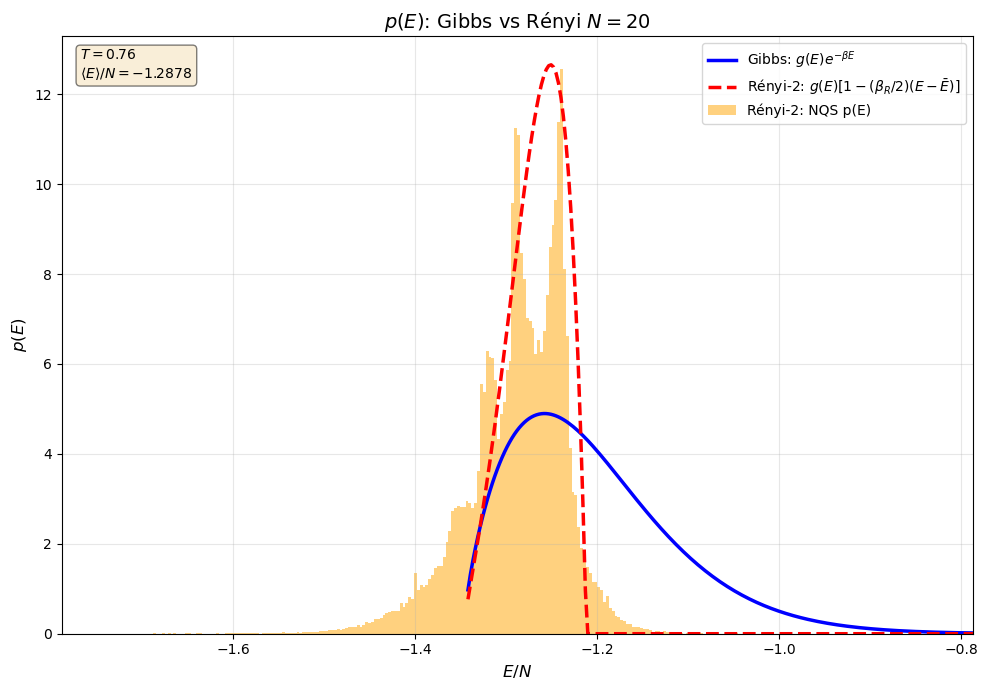

In [29]:
#  p(E): Gibbs exacto (JW) vs Rényi teórico vs vstate
def compare_p_renyi_gibbs(N, N_A, T_dos, hi_extended, H_extended, plot=False, xlims=None, ylim=None):

    # 1. Energías locales del vstate (muestras de E)
    sampler = nk.sampler.ARDirectSampler(hi_extended)
    model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
    vstate = nk.vqs.MCState(sampler, model, n_samples=40960)

    load_params(N, N_A, hamiltonian_idx, T_dos, vstate)
    vstate.n_samples = 40960*4
    vstate.chunk_size = 2**10

    # local_estimators devuelve E_loc para cada muestra: shape (n_samples,)
    E_loc = np.real(vstate.local_estimators(H_extended).reshape(-1))
    E_loc_per_site = E_loc / N
    expect_H = vstate.expect(H_extended).mean.real / N

    # 2. Histograma del vstate
    counts, bin_edges = np.histogram(E_loc_per_site, bins=500, density=True)
    E_vstate = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    p_vstate = counts
    dE_vstate = E_vstate[1] - E_vstate[0]
    p_vstate /= p_vstate.sum() * dE_vstate

    # 3. g(E) exacta JW (saddle point)
    def jw_dos_saddle(N, J, h, n_points=1000):
        m = np.arange(N)
        eps_k = 2*np.sqrt(J**2 + h**2 - 2*J*h*np.cos(2*np.pi*(m+0.5)/N))
        E_min = -np.sum(eps_k/2) / N
        E_max = np.sum(eps_k/2) / N

        def log_Z(beta):
            return np.sum(np.log(2*np.cosh(beta * eps_k / 2)))

        def mean_E(beta):
            return -np.sum(eps_k/2 * np.tanh(beta * eps_k/2)) / N

        E_arr = np.linspace(E_min*0.999, E_max*0.999, n_points)
        log_g = np.zeros(n_points)
        for i, E in enumerate(E_arr):
            b_star = brentq(lambda b: mean_E(b) - E, -500, 500, xtol=1e-12)
            log_g[i] = b_star * E * N + log_Z(b_star)

        dE = E_arr[1] - E_arr[0]
        g = np.exp(log_g - log_g.max())
        g /= g.sum() * dE
        return E_arr, g, dE

    E_jw, g_jw, dE_jw = jw_dos_saddle(N, -J_ZZ, -h_x)

    # 4. Funciones auxiliares
    def compute_variance(E_arr, p, dE):
        """Calcula media y varianza de una distribución p(E)"""
        mean = np.sum(E_arr * p) * dE
        variance = np.sum((E_arr - mean)**2 * p) * dE
        return mean, variance

    def p_gibbs_safe(g, E_arr, N, beta, dE):
        log_w = np.log(g + 1e-300) - beta * E_arr * N
        log_w_max = np.max(log_w)
        w = np.exp(log_w - log_w_max)
        Z = np.sum(w) * dE
        p = w / Z
        return p

    def p_renyi_safe(g, E_arr, N, beta_R, E_mean, dE):
        linear_factor = 1.0 - (beta_R / 2) * N * (E_arr - E_mean)
        linear_factor = np.maximum(linear_factor, 0.0)
        
        log_w = np.log(g + 1e-300) + np.log(linear_factor + 1e-300)
        log_w -= log_w.max()
        w = np.exp(log_w)
        p = w / (w.sum() * dE)
        return p, linear_factor

    def solve_renyi_selfconsistency(E_arr, g, N, beta_R, dE, tol=1e-10):
        w0 = np.exp(-beta_R * E_arr * N)
        w0 /= w0.sum()
        e_bar = np.sum(E_arr * g * w0) / np.sum(g * w0)
        
        for _ in range(1000):
            linear = np.maximum(1.0 - (beta_R/2) * N * (E_arr - e_bar), 0.0)
            w = g * linear
            Z = w.sum() * dE
            if Z == 0:
                break
            e_bar_new = np.sum(E_arr * w) * dE / Z
            if abs(e_bar_new - e_bar) < tol:
                break
            e_bar = e_bar_new
        return e_bar

    # 5. Calcular curvas teóricas
    beta_R = 1.0 / T_dos

    # E_mean_renyi = solve_renyi_selfconsistency(E_jw, g_jw, N, beta_R, dE_jw)
    E_mean_renyi = expect_H

    # Gibbs: p(E)
    p_gibbs = p_gibbs_safe(g_jw, E_jw, N, beta_R, dE_jw)
    mean_gibbs, var_gibbs = compute_variance(E_jw, p_gibbs, dE_jw)

    # Rényi teórico: p(E)
    p_renyi, linear_factor = p_renyi_safe(g_jw, E_jw, N, beta_R, E_mean_renyi, dE_jw)
    mean_renyi, var_renyi = compute_variance(E_jw, p_renyi, dE_jw)

    # vstate (histograma)
    mean_vstate, var_vstate = compute_variance(E_vstate, p_vstate, dE_vstate)

    # 6. Plot
    if plot:
        plt.figure(figsize=(10, 7))
        plt.plot(E_jw, p_gibbs, 'b-', lw=2.5, label='Gibbs: $g(E) e^{-\\beta E}$')
        plt.plot(E_jw, p_renyi, 'r--', lw=2.5, label='Rényi-2: $g(E) [1 - (\\beta_R/2)(E-\\bar{E})]$')
        plt.bar(E_vstate, p_vstate, width=dE_vstate, alpha=0.5, color='orange',
                label=f'Rényi-2: NQS p(E)')
        
        plt.xlabel(r'$E/N$', fontsize=12)
        plt.ylabel(r'$p(E)$', fontsize=12)
        plt.title(rf'$p(E)$: Gibbs vs Rényi $N={N}$', fontsize=14)
        plt.legend(fontsize=10, loc='best')
        plt.grid(alpha=0.3)
        
        if xlims is not None:
            plt.xlim(expect_H - xlims[0], expect_H + xlims[1])
        if ylim is not None:
            plt.ylim(0, ylim)

        info_text = f'$T = {T_dos}$\n$\\langle E \\rangle / N = {E_mean_renyi:.4f}$'
        plt.text(0.02, 0.98, info_text, transform=plt.gca().transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        plt.tight_layout()
        plt.show()

    # 7. Devolver resultados
    results = {
        'gibbs': {'mean': mean_gibbs, 'variance': var_gibbs},
        'renyi': {'mean': mean_renyi, 'variance': var_renyi, 'E_bar': E_mean_renyi},
        'vstate': {'mean': mean_vstate, 'variance': var_vstate, 'expect_H': expect_H},
        'parameters': {'N': N, 'T': T_dos, 'beta': beta_R}
    }
    
    return results

_ = compare_p_renyi_gibbs(N, N_A, 0.76, hi_extended, H_extended, plot=True, xlims=[0.5, 0.5])

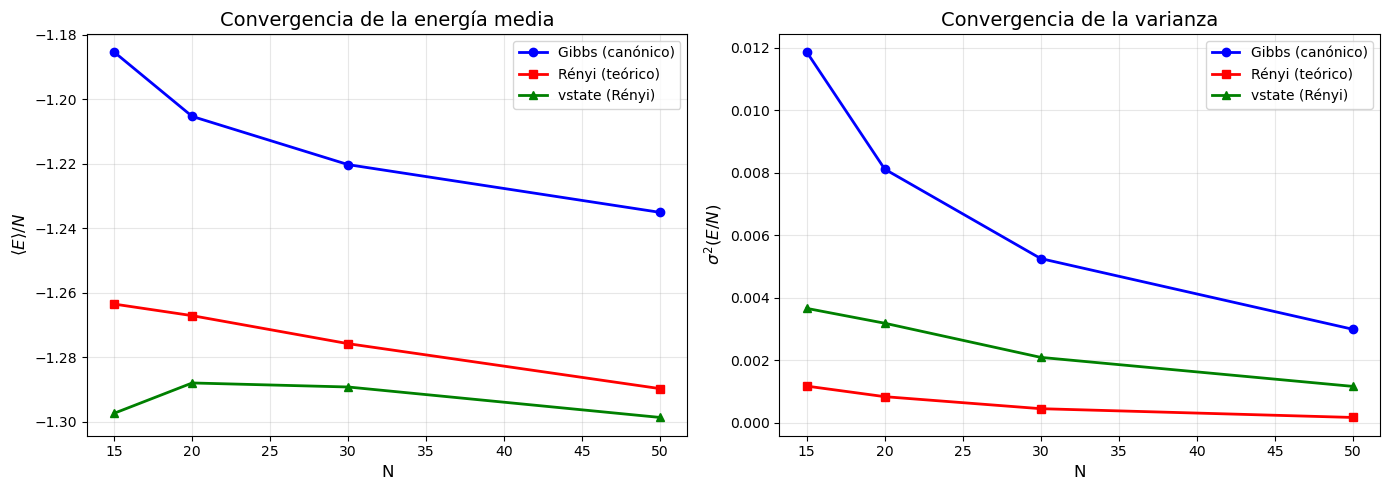

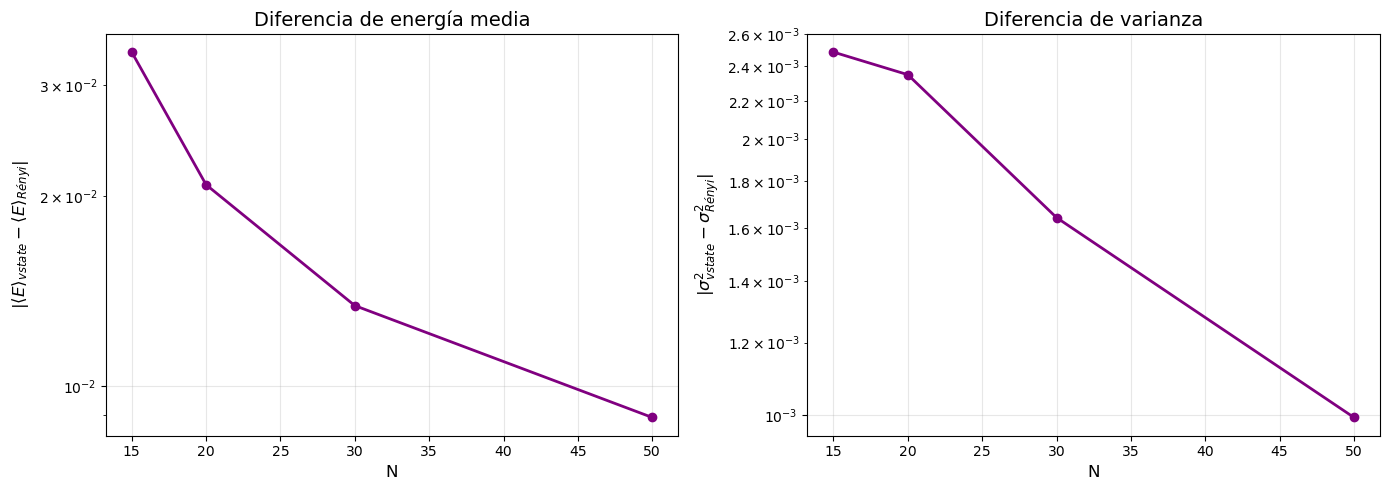


RESUMEN DE CONVERGENCIA
N      Gibbs mean   Rényi mean   vstate mean  Gibbs var    Rényi var    vstate var  
----------------------------------------------------------------------
15     -1.185400    -1.263467    -1.297296    0.011858     0.001173     0.003659    
20     -1.205323    -1.267053    -1.287908    0.008113     0.000835     0.003184    
30     -1.220267    -1.275737    -1.289158    0.005253     0.000450     0.002092    
50     -1.235058    -1.289669    -1.298595    0.002992     0.000170     0.001164    

ANÁLISIS DE CONVERGENCIA
--------------------------------------------------
Para N=50 (mayor N):
  Diferencia de medias (vstate - Rényi): -0.008925
  Diferencia de varianzas (vstate - Rényi): 0.000994
  Diferencia de medias (Rényi - Gibbs): -0.054612
  Diferencia de varianzas (Rényi - Gibbs): -0.002822


In [65]:
N_list = [15, 20, 30, 50]
N_A_list = [10, 20, 10, 10]
T_list = [0.76, 0.75, 0.76, 0.76]

results_gibbs = {'mean': [], 'variance': []}
results_renyi = {'mean': [], 'variance': []}
results_renyi_vstate = {'mean': [], 'variance': []}

for N, N_A, T in zip(N_list, N_A_list, T_list):

    hi_system = nk.hilbert.Spin(s=1/2, N=N)
    hi_extended = nk.hilbert.Spin(s=1/2, N=N+N_A)
    H_system, H_extended = hamiltonian_system_and_extended(J_ZZ, J_XX, h_x, h_z, N, hi_system, hi_extended)

    resultados = compare_p_renyi_gibbs(N, N_A, T, hi_extended, H_extended, plot=False)
    
    results_gibbs['mean'].append(resultados['gibbs']['mean'])
    results_gibbs['variance'].append(resultados['gibbs']['variance'])
    
    results_renyi['mean'].append(resultados['renyi']['mean'])
    results_renyi['variance'].append(resultados['renyi']['variance'])
    
    results_renyi_vstate['mean'].append(resultados['vstate']['mean'])
    results_renyi_vstate['variance'].append(resultados['vstate']['variance'])

N_array = np.array(N_list)
gibbs_mean = np.array(results_gibbs['mean'])
gibbs_var = np.array(results_gibbs['variance'])
renyi_mean = np.array(results_renyi['mean'])
renyi_var = np.array(results_renyi['variance'])
vstate_mean = np.array(results_renyi_vstate['mean'])
vstate_var = np.array(results_renyi_vstate['variance'])

# ── PLOTS ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel (a): Energía media vs N
ax1 = axes[0]
ax1.plot(N_array, gibbs_mean, 'b-o', lw=2, markersize=6, label='Gibbs (canónico)')
ax1.plot(N_array, renyi_mean, 'r-s', lw=2, markersize=6, label='Rényi (teórico)')
ax1.plot(N_array, vstate_mean, 'g-^', lw=2, markersize=6, label='vstate (Rényi)')
ax1.set_xlabel('N', fontsize=12)
ax1.set_ylabel(r'$\langle E \rangle / N$', fontsize=12)
ax1.set_title('Convergencia de la energía media', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Panel (b): Varianza vs N
ax2 = axes[1]
ax2.plot(N_array, gibbs_var, 'b-o', lw=2, markersize=6, label='Gibbs (canónico)')
ax2.plot(N_array, renyi_var, 'r-s', lw=2, markersize=6, label='Rényi (teórico)')
ax2.plot(N_array, vstate_var, 'g-^', lw=2, markersize=6, label='vstate (Rényi)')
ax2.set_xlabel('N', fontsize=12)
ax2.set_ylabel(r'$\sigma^2(E/N)$', fontsize=12)
ax2.set_title('Convergencia de la varianza', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Plot adicional: Diferencia entre vstate y Rényi ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Diferencia de medias
ax1 = axes[0]
diff_mean = np.abs(vstate_mean - renyi_mean)
ax1.semilogy(N_array, diff_mean, 'purple', lw=2, marker='o', markersize=6)
ax1.set_xlabel('N', fontsize=12)
ax1.set_ylabel(r'$|\langle E \rangle_{vstate} - \langle E \rangle_{Rényi}|$', fontsize=12)
ax1.set_title('Diferencia de energía media', fontsize=14)
ax1.grid(alpha=0.3)

# Diferencia de varianzas
ax2 = axes[1]
diff_var = np.abs(vstate_var - renyi_var)
ax2.semilogy(N_array, diff_var, 'purple', lw=2, marker='o', markersize=6)
ax2.set_xlabel('N', fontsize=12)
ax2.set_ylabel(r'$|\sigma^2_{vstate} - \sigma^2_{Rényi}|$', fontsize=12)
ax2.set_title('Diferencia de varianza', fontsize=14)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Información final ─────────────────────────────────────────────────────
print("\n" + "="*70)
print("RESUMEN DE CONVERGENCIA")
print("="*70)
print(f"{'N':<6} {'Gibbs mean':<12} {'Rényi mean':<12} {'vstate mean':<12} {'Gibbs var':<12} {'Rényi var':<12} {'vstate var':<12}")
print("-"*70)
for i, N in enumerate(N_list):
    print(f"{N:<6} {gibbs_mean[i]:<12.6f} {renyi_mean[i]:<12.6f} {vstate_mean[i]:<12.6f} "
          f"{gibbs_var[i]:<12.6f} {renyi_var[i]:<12.6f} {vstate_var[i]:<12.6f}")
print("="*70)

# ── Análisis de convergencia ─────────────────────────────────────────────
print("\nANÁLISIS DE CONVERGENCIA")
print("-"*50)
print(f"Para N={N_list[-1]} (mayor N):")
print(f"  Diferencia de medias (vstate - Rényi): {vstate_mean[-1] - renyi_mean[-1]:.6f}")
print(f"  Diferencia de varianzas (vstate - Rényi): {vstate_var[-1] - renyi_var[-1]:.6f}")
print(f"  Diferencia de medias (Rényi - Gibbs): {renyi_mean[-1] - gibbs_mean[-1]:.6f}")
print(f"  Diferencia de varianzas (Rényi - Gibbs): {renyi_var[-1] - gibbs_var[-1]:.6f}")
print("="*70)

In [ ]:
N_list = [3, 4, 6, 10]
N_A_list = N_list

fig, axes = plt.subplots(1, 3, figsize=(15, 4))  

exact_drawn = True

for N, N_A in zip(N_list, N_A_list):
    T_array = check_temperatures(N, N_A, hamiltonian_idx)
    T_array = T_array[T_array >= 0.05]
    if N == 10:
        exact_drawn = False
    print(f"\nProcesando N = {N}")

    hi_system = nk.hilbert.Spin(s=1/2, N=N)
    hi_extended = nk.hilbert.Spin(s=1/2, N=2*N)
    H_system, H_extended = hamiltonian_system_and_extended(J_ZZ, J_XX, h_x, h_z, N, hi_system, hi_extended)

    # diagonalización exacta
    if not exact_drawn:
        H_matrix = H_system.to_dense()
        eigvals, eigvecs = np.linalg.eigh(H_matrix)

    O_x = sum(sigmax(hi_system, i) for i in range(N)) / N
    O_zz = sum(sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N) for i in range(N)) / N
    O_xx = sum(sigmax(hi_system, i) @ sigmax(hi_system, (i + 1) % N) for i in range(N)) / N  
    O_x_ext = sum(sigmax(hi_extended, i) for i in range(N)) / N
    O_zz_ext = sum(sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N) for i in range(N)) / N
    O_xx_ext = sum(sigmax(hi_extended, i) @ sigmax(hi_extended, (i + 1) % N) for i in range(N)) / N 

    sampler = nk.sampler.ARDirectSampler(hi_extended)
    model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
    vstate = nk.vqs.MCState(sampler, model, n_samples=40960)
    if N>40:
        vstate.chunk_size = 256*4


    energies_renyi = []
    sx_renyi = []
    szz_renyi = []
    sxx_renyi = []  
    energies_exact = []
    sx_exact = []
    szz_exact = []
    sxx_exact = []  

    for T in tqdm(T_array, desc=f"N={N}"):
        # Rényi
        load_params(N, N_A, hamiltonian_idx, T, vstate)
        E = vstate.expect(H_extended).mean
        e_density = E / N
        mx = vstate.expect(O_x_ext).mean
        corr_zz = vstate.expect(O_zz_ext).mean
        corr_xx = vstate.expect(O_xx_ext).mean 
        energies_renyi.append(e_density)
        sx_renyi.append(mx)
        szz_renyi.append(corr_zz)
        sxx_renyi.append(corr_xx)  

        if not exact_drawn:
            beta = 1.0 / T
            weights = np.exp(-beta * eigvals)
            Z = np.sum(weights)
            E_exact = np.sum(eigvals * weights) / Z
            e_density_exact = E_exact / N
            mx_exact = canonical_expectation(O_x, T, eigvals, eigvecs)
            corr_zz_exact = canonical_expectation(O_zz, T, eigvals, eigvecs)
            corr_xx_exact = canonical_expectation(O_xx, T, eigvals, eigvecs)  
            energies_exact.append(e_density_exact)
            sx_exact.append(mx_exact)
            szz_exact.append(corr_zz_exact)
            sxx_exact.append(corr_xx_exact)  

    
    axes[0].scatter(energies_renyi, sx_renyi, s=15, label=f"N={N}")
    axes[1].scatter(energies_renyi, szz_renyi, s=15, label=f"N={N}")
    axes[2].scatter(energies_renyi, sxx_renyi, s=15, label=f"N={N}")  

    
    if not exact_drawn:
        axes[0].plot(energies_exact, sx_exact, color="gray", linewidth=2, label="exact")
        axes[1].plot(energies_exact, szz_exact, color="gray", linewidth=2, label="exact")
        axes[2].plot(energies_exact, sxx_exact, color="gray", linewidth=2, label="exact") 
        exact_drawn = True


axes[0].set_xlabel(r"$\langle H \rangle / N$")
axes[1].set_xlabel(r"$\langle H \rangle / N$")
axes[2].set_xlabel(r"$\langle H \rangle / N$")

axes[0].set_ylabel(r"$\langle \sigma^x \rangle$")
axes[1].set_ylabel(r"$\langle \sigma^z \sigma^z \rangle$")
axes[2].set_ylabel(r"$\langle \sigma^x \sigma^x \rangle$") 

for ax in axes:
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
save = False
fontsize = 14
N_list = [15, 20, 30, 50, 100]
N_A_list = [10, 20, 10, 10, 15]

if save:
    import matplotlib
    import matplotlib.pyplot as plt
    matplotlib.use("pgf")
    matplotlib.rcParams.update({
        "pgf.texsystem": "pdflatex",
        "font.family": "serif",
        "text.usetex": True,
        "pgf.rcfonts": False,
        "font.size": fontsize,
        "axes.titlesize": fontsize,
        "axes.labelsize": fontsize,
        "legend.fontsize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "figure.titlesize": fontsize,
    })

    def save_fig(fig, name, subdir="plots/MRE"):
        import os
        base = os.path.join("..", subdir)
        os.makedirs(base, exist_ok=True)
        for ext in ("pgf", "pdf"):
            fig.savefig(os.path.join(base, f"{name}.{ext}"), bbox_inches="tight")
        print(f"Guardado: {base}/{name}.[pgf|pdf]")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Límite termodinámico
Nk = 4000
k = np.linspace(0, np.pi, Nk)
dk = np.pi / Nk

J = abs(J_ZZ)
h = abs(h_x)

energies_td = []
sx_td = []         
szz_td = []

T_array = np.linspace(0.01, 0.6, 30)

for T in T_array:
    beta = 1.0 / T
    eps_k = 2 * np.sqrt(J**2 + h**2 - 2 * J * h * np.cos(k))
    tanh_term = np.tanh(beta * eps_k / 2)
    # Energía por sitio 
    e = - np.sum((eps_k / 2) * tanh_term) * dk / np.pi
    # <σx>
    mx = np.sum((h - J * np.cos(k)) / eps_k * tanh_term) * dk / np.pi
    # <σz σz>
    corr = np.sum((J - h * np.cos(k))/eps_k* tanh_term) * dk / np.pi
    energies_td.append(e)
    szz_td.append(corr*2)
    sx_td.append(mx*2)   

for N, N_A in zip(N_list, N_A_list):
    T_array = check_temperatures(N, N_A, hamiltonian_idx)
    T_array = T_array[T_array >= 0.05]
    print(f"\nProcesando N = {N}")

    # Hilbert spaces
    hi_system = nk.hilbert.Spin(s=1/2, N=N)
    hi_extended = nk.hilbert.Spin(s=1/2, N=N+N_A)

    # Hamiltonianos
    H_system, H_extended = hamiltonian_system_and_extended(J_ZZ, 0, h_x, 0, N, hi_system, hi_extended)

    # Observables
    O_x = sum(sigmax(hi_system, i) for i in range(N)) / N
    O_zz = sum(sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N) for i in range(N)) / N
    O_x_ext = sum(sigmax(hi_extended, i) for i in range(N)) / N
    O_zz_ext = sum(sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N) for i in range(N)) / N

    # Vstate
    sampler = nk.sampler.ARDirectSampler(hi_extended)
    model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
    vstate = nk.vqs.MCState(sampler, model, n_samples=40960)
    if N>40:
        vstate.chunk_size = 256*4

    energies_renyi = []
    sx_renyi = []
    szz_renyi = []

    # Loop en temperatura
    for T in tqdm(T_array, desc=f"N={N}"):
        load_params(N, N_A, hamiltonian_idx, T, vstate)
        if N>50:
            vstate.chunk_size = 256
        E = vstate.expect(H_extended).mean
        e_density = E / N
        mx = vstate.expect(O_x_ext).mean
        corr = vstate.expect(O_zz_ext).mean
        energies_renyi.append(e_density)
        sx_renyi.append(mx)
        szz_renyi.append(corr)

    # Plot Rényi
    axes[0].scatter(energies_renyi, sx_renyi, s=15, label=f"N={N}")
    axes[1].scatter(energies_renyi, szz_renyi, s=15, label=f"N={N}")


axes[0].plot(energies_td, sx_td, color="gray", linewidth=3, label="thermodynamic limit")
axes[1].plot(energies_td, szz_td, color="gray", linewidth=3, label="thermodynamic limit")

axes[0].set_xlabel(r"$\langle H \rangle / N$")
axes[1].set_xlabel(r"$\langle H \rangle / N$")

axes[0].set_ylabel(r"$\langle \sigma^x \rangle$")
axes[1].set_ylabel(r"$\langle \sigma^z \sigma^z \rangle$")

axes[0].grid(True)
axes[1].grid(True)

axes[0].legend()
axes[1].legend()

plt.tight_layout()
if save:
    save_fig(fig, f"Observables_vs_energy_{hamiltonian_idx}")
else:
    plt.show()

In [ ]:
save = False
fontsize = 14
N_list = [30, 50, 100]
N_A_list = [10, 10, 15]

# Límite termodinámico
Nk = 4000
k = np.linspace(0, np.pi, Nk)
dk = np.pi / Nk

J = -(J_ZZ)
h = -(h_x)

energies_td = []
sx_td = []         
szz_td = []

T_array = np.linspace(0.01, 0.6, 30)

for T in T_array:
    beta = 1.0 / T
    eps_k = 2 * np.sqrt(J**2 + h**2 - 2 * J * h * np.cos(k))
    tanh_term = np.tanh(beta * eps_k / 2)
    # Energía por sitio 
    e = - np.sum((eps_k / 2) * tanh_term) * dk / np.pi
    # <σx>
    mx = np.sum((h - J * np.cos(k)) / eps_k * tanh_term) * dk / np.pi
    # <σz σz>
    corr = np.sum((J - h * np.cos(k))/eps_k* tanh_term) * dk / np.pi
    energies_td.append(e)
    szz_td.append(corr*2)
    sx_td.append(mx*2)   


renyi_results = [] 

for N, N_A in zip(N_list, N_A_list):
    T_array = check_temperatures(N, N_A, hamiltonian_idx)
    T_array = T_array[T_array >= 0.05]
    print(f"\nProcesando N = {N}")

    # Hilbert spaces
    hi_system = nk.hilbert.Spin(s=1/2, N=N)
    hi_extended = nk.hilbert.Spin(s=1/2, N=N+N_A)

    # Hamiltonianos
    H_system, H_extended = hamiltonian_system_and_extended(J_ZZ, 0, h_x, 0, N, hi_system, hi_extended)

    # Observables
    O_x = sum(sigmax(hi_system, i) for i in range(N)) / N
    O_zz = sum(sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N) for i in range(N)) / N
    O_x_ext = sum(sigmax(hi_extended, i) for i in range(N)) / N
    O_zz_ext = sum(sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N) for i in range(N)) / N

    # Vstate
    sampler = nk.sampler.ARDirectSampler(hi_extended)
    model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
    vstate = nk.vqs.MCState(sampler, model, n_samples=40960)
    if N>40:
        vstate.chunk_size = 256*4

    energies_renyi = []
    sx_renyi = []
    szz_renyi = []

    # Loop en temperatura
    for T in tqdm(T_array, desc=f"N={N}"):
        load_params(N, N_A, hamiltonian_idx, T, vstate)
        if N>50:
            vstate.chunk_size = 256
        E = vstate.expect(H_extended).mean
        e_density = E / N
        mx = vstate.expect(O_x_ext).mean
        corr = vstate.expect(O_zz_ext).mean
        energies_renyi.append(e_density)
        sx_renyi.append(mx)
        szz_renyi.append(corr)
    
    renyi_results.append((N, energies_renyi, sx_renyi, szz_renyi))

In [ ]:
if save:
    import matplotlib
    import matplotlib.pyplot as plt
    matplotlib.use("pgf")
    matplotlib.rcParams.update({
        "pgf.texsystem": "pdflatex",
        "font.family": "serif",
        "text.usetex": True,
        "pgf.rcfonts": False,
        "font.size": fontsize,
        "axes.titlesize": fontsize,
        "axes.labelsize": fontsize,
        "legend.fontsize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "figure.titlesize": fontsize,
    })

    def save_fig(fig, name, subdir="plots/MRE"):
        import os
        base = os.path.join("..", subdir)
        os.makedirs(base, exist_ok=True)
        for ext in ("pgf", "pdf"):
            fig.savefig(os.path.join(base, f"{name}.{ext}"), bbox_inches="tight")
        print(f"Guardado: {base}/{name}.[pgf|pdf]")
else:
    import matplotlib.pyplot as plt

discard_list = [1, 20, 0, 1]

# Crear figura
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot resultados de Rényi
for (N, energies_renyi, sx_renyi, szz_renyi), n_discard in zip(renyi_results, discard_list):
    if n_discard > 0:
        energies_trimmed = energies_renyi[:-n_discard] if n_discard > 0 else energies_renyi
        sx_trimmed = sx_renyi[:-n_discard]
        szz_trimmed = szz_renyi[:-n_discard]
    else:
        energies_trimmed = energies_renyi
        sx_trimmed = sx_renyi
        szz_trimmed = szz_renyi
    
    # Dibujar línea conectando los puntos (en orden)
    axes[0].plot(energies_trimmed, sx_trimmed, '-', linewidth=1, alpha=0.5, label=f"N={N}")
    axes[0].scatter(energies_trimmed, sx_trimmed, s=15)
    
    axes[1].plot(energies_trimmed, szz_trimmed, '-', linewidth=1, alpha=0.5, label=f"N={N}")
    axes[1].scatter(energies_trimmed, szz_trimmed, s=15)

# Plot límite termodinámico
axes[0].plot(energies_td, sx_td, color="gray", linewidth=3, label="T.L. Gibbs")
axes[1].plot(energies_td, szz_td, color="gray", linewidth=3, label="T.L. Gibbs")

# Etiquetas y formato
axes[0].set_xlabel(r"$\langle H \rangle / N$")
axes[1].set_xlabel(r"$\langle H \rangle / N$")

axes[0].set_ylabel(r"$\langle \sigma^x \rangle$")
axes[1].set_ylabel(r"$\langle \sigma^z \sigma^z \rangle$")

axes[0].grid(True)
axes[1].grid(True)

axes[0].legend()
axes[1].legend()

plt.tight_layout()

# Guardar o mostrar
if save:
    save_fig(fig, f"Observables_vs_energy_{hamiltonian_idx}")
else:
    plt.show()